In [1]:
!pip install pandas numpy matplotlib scikit-learn groq

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [3]:
df=pd.read_csv(r'C:\Users\sushm\Downloads\sales_data_sample.csv',encoding='latin-1')
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [4]:
df.shape
df.head(3)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium


In [5]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [6]:
print("columns in dataset",df.columns.tolist())

columns in dataset ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


In [7]:
#null values
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [8]:
#clean the data
#drop columns that's not required
df=df.drop(columns=['ADDRESSLINE1', 'ADDRESSLINE2', 'STATE', 'TERRITORY', 'PHONE', 'CONTACTFIRSTNAME', 'CONTACTLASTNAME', 'POSTALCODE'])
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,CITY,COUNTRY,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,NYC,USA,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,Reims,France,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,Paris,France,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,Pasadena,USA,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,San Francisco,USA,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,Ships,54,S72_3212,Euro Shopping Channel,Madrid,Spain,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",Oulu,Finland,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,Ships,54,S72_3212,Euro Shopping Channel,Madrid,Spain,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,Ships,54,S72_3212,Alpha Cognac,Toulouse,France,Small


In [9]:
df['ORDERDATE']=pd.to_datetime(df['ORDERDATE'])
df


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,CITY,COUNTRY,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,NYC,USA,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,Reims,France,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,Paris,France,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,Pasadena,USA,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,San Francisco,USA,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,Ships,54,S72_3212,Euro Shopping Channel,Madrid,Spain,Small
2819,10373,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",Oulu,Finland,Medium
2820,10386,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,Ships,54,S72_3212,Euro Shopping Channel,Madrid,Spain,Medium
2821,10397,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,Ships,54,S72_3212,Alpha Cognac,Toulouse,France,Small


In [10]:
#extract useful time features
df['MONTH']=df['ORDERDATE'].dt.month
df['YEAR']=df['ORDERDATE'].dt.year
df['QUARTER']=df['ORDERDATE'].dt.quarter
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,CITY,COUNTRY,DEALSIZE,MONTH,YEAR,QUARTER
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,NYC,USA,Small,2,2003,1
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,Reims,France,Small,5,2003,2
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,Paris,France,Medium,7,2003,3
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,Pasadena,USA,Medium,8,2003,3
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,San Francisco,USA,Medium,10,2003,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,Ships,54,S72_3212,Euro Shopping Channel,Madrid,Spain,Small,12,2004,4
2819,10373,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",Oulu,Finland,Medium,1,2005,1
2820,10386,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,Ships,54,S72_3212,Euro Shopping Channel,Madrid,Spain,Medium,3,2005,1
2821,10397,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,Ships,54,S72_3212,Alpha Cognac,Toulouse,France,Small,3,2005,1


In [11]:
print("cleaned data",df.shape)
df.isnull().sum()

cleaned data (2823, 20)


ORDERNUMBER        0
QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALES              0
ORDERDATE          0
STATUS             0
QTR_ID             0
MONTH_ID           0
YEAR_ID            0
PRODUCTLINE        0
MSRP               0
PRODUCTCODE        0
CUSTOMERNAME       0
CITY               0
COUNTRY            0
DEALSIZE           0
MONTH              0
YEAR               0
QUARTER            0
dtype: int64

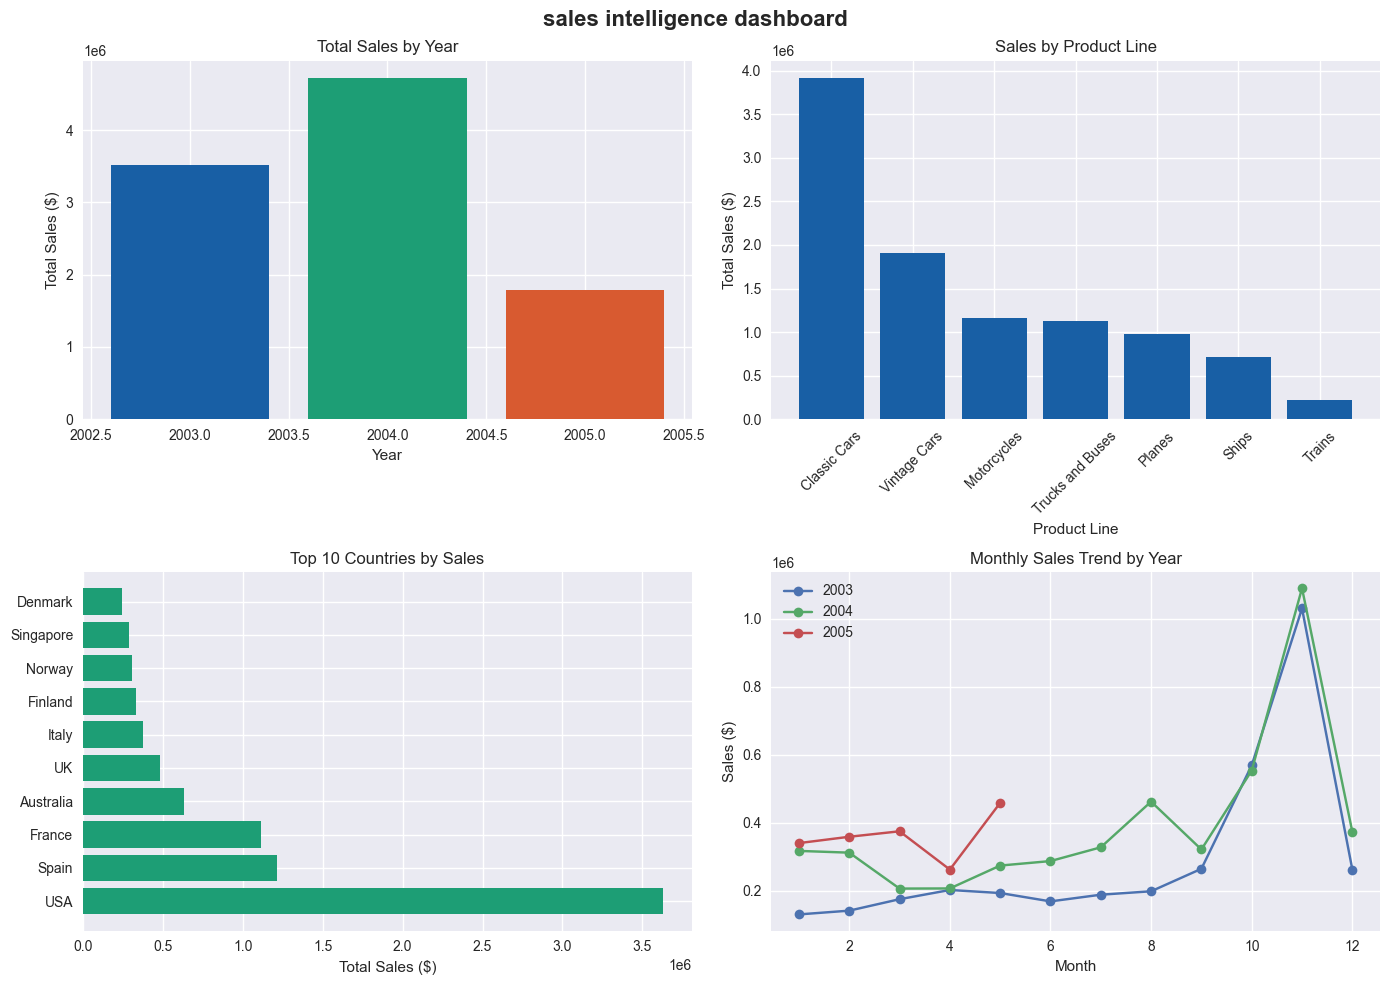


Key Insights:
Total Revenue: $10,032,628.85
Best Year: 2004
Best Product Line: Classic Cars
Top Country: USA


In [12]:
plt.style.use('seaborn-v0_8')
fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle('sales intelligence dashboard',fontsize=16,fontweight='bold')
#sales by year
yearly_sales = df.groupby('YEAR')['SALES'].sum()
axes[0,0].bar(yearly_sales.index, yearly_sales.values, color=['#185FA5', '#1D9E75', '#D85A30'])
axes[0,0].set_title('Total Sales by Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Total Sales ($)')

#chart 2-sales by product line--product line is seeries of product
product_sales = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
axes[0,1].bar(product_sales.index, product_sales.values, color='#185FA5')
axes[0,1].set_title('Sales by Product Line')
axes[0,1].set_xlabel('Product Line')
axes[0,1].set_ylabel('Total Sales ($)')
axes[0,1].tick_params(axis='x', rotation=45)
#chart 3--sales by country
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(10)
axes[1,0].barh(country_sales.index, country_sales.values, color='#1D9E75')
axes[1,0].set_title('Top 10 Countries by Sales')
axes[1,0].set_xlabel('Total Sales ($)')
#chart 4-monthly sales trend
monthly_sales = df.groupby(['YEAR', 'MONTH'])['SALES'].sum().reset_index()
for year in monthly_sales['YEAR'].unique():
    data = monthly_sales[monthly_sales['YEAR'] == year]
    axes[1,1].plot(data['MONTH'], data['SALES'], marker='o', label=str(year))
axes[1,1].set_title('Monthly Sales Trend by Year')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Sales ($)')
axes[1,1].legend()
plt.tight_layout()
plt.savefig('sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insights:")
print(f"Total Revenue: ${df['SALES'].sum():,.2f}")
print(f"Best Year: {yearly_sales.idxmax()}")
print(f"Best Product Line: {product_sales.idxmax()}")
print(f"Top Country: {country_sales.idxmax()}")





In [13]:
import sqlite3
#create database
con=sqlite3.connect('sales_intelligence.db')
#cursor-pointer to execute sql commands
cursor=con.cursor


In [14]:
df.to_sql('sales',con,if_exists='replace',index='False')
print("database created sucessfully")
print(f"{len(df)}rows loaded into sql table")


database created sucessfully
2823rows loaded into sql table


In [15]:
#query1--total revenue by country
print("totall revenue by country")
q1=pd.read_sql_query(""" 
    SELECT COUNTRY,
    ROUND(SUM(SALES),2) as TOTAL_SALES,
    COUNT(ORDERNUMBER) as TOTAL_ORDERS
    FROM sales
    GROUP BY COUNTRY
    ORDER BY TOTAL_SALES DESC
    LIMIT 10
    """,con)
print(q1)

totall revenue by country
     COUNTRY  TOTAL_SALES  TOTAL_ORDERS
0        USA   3627982.83          1004
1      Spain   1215686.92           342
2     France   1110916.52           314
3  Australia    630623.10           185
4         UK    478880.46           144
5      Italy    374674.31           113
6    Finland    329581.91            92
7     Norway    307463.70            85
8  Singapore    288488.41            79
9    Denmark    245637.15            63


In [16]:
#best performing product lines
q2=pd.read_sql_query("""
  SELECT PRODUCTLINE,
    ROUND(SUM(SALES),2) AS TOTAL_SALES,
    ROUND(AVG(SALES),2)AS AVG_ORDER_VALUE
    FROM sales
    GROUP BY PRODUCTLINE
    ORDER BY TOTAL_SALES DESC
    """,con)
print(q2)

        PRODUCTLINE  TOTAL_SALES  AVG_ORDER_VALUE
0      Classic Cars   3919615.66          4053.38
1      Vintage Cars   1903150.84          3135.34
2       Motorcycles   1166388.34          3523.83
3  Trucks and Buses   1127789.84          3746.81
4            Planes    975003.57          3186.29
5             Ships    714437.13          3053.15
6            Trains    226243.47          2938.23


In [17]:
#yearly growth
q3=pd.read_sql_query("""
  SELECT YEAR,
  ROUND(SUM(SALES),2) as TOTAL_VALUES,
  COUNT(ORDERNUMBER) as TOTAL_ORDERS
  FROM sales
  GROUP BY YEAR
  ORDER BY YEAR
  """,con)
print(q3)

   YEAR  TOTAL_VALUES  TOTAL_ORDERS
0  2003    3516979.54          1000
1  2004    4724162.60          1345
2  2005    1791486.71           478


In [18]:
print("\n--- Query 4: Top 5 Customers ---")
query4 = pd.read_sql_query("""
    SELECT CUSTOMERNAME,
           ROUND(SUM(SALES), 2) as TOTAL_SPENT,
           COUNT(ORDERNUMBER) as TOTAL_ORDERS
    FROM sales
    GROUP BY CUSTOMERNAME
    ORDER BY TOTAL_SPENT DESC
    LIMIT 5
""", con)
print(query4)

# Query 5 - Best month to sell
print("\n--- Query 5: Best Month for Sales ---")
query5 = pd.read_sql_query("""
    SELECT MONTH,
           ROUND(AVG(SALES), 2) as AVG_SALES,
           ROUND(SUM(SALES), 2) as TOTAL_SALES
    FROM sales
    GROUP BY MONTH
    ORDER BY TOTAL_SALES DESC
""", con)
print(query5)


--- Query 4: Top 5 Customers ---
                   CUSTOMERNAME  TOTAL_SPENT  TOTAL_ORDERS
0         Euro Shopping Channel    912294.11           259
1  Mini Gifts Distributors Ltd.    654858.06           180
2    Australian Collectors, Co.    200995.41            55
3            Muscle Machine Inc    197736.94            48
4             La Rochelle Gifts    180124.90            53

--- Query 5: Best Month for Sales ---
    MONTH  AVG_SALES  TOTAL_SALES
0      11    3549.22   2118885.67
1      10    3536.96   1121215.22
2       5    3666.56    923972.56
3       2    3618.04    810441.90
4       1    3431.77    785874.44
5       3    3558.97    754501.39
6       4    3760.62    669390.96
7       8    3451.89    659310.57
8      12    3526.00    634679.12
9       9    3419.44    584724.27
10      7    3651.60    514875.97
11      6    3471.43    454756.78


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import LabelEncoder


In [20]:
df_ml = df.copy()
lr=LabelEncoder()
df_ml['PRODUCTLINE_ENC'] = lr.fit_transform(df_ml['PRODUCTLINE'])
df_ml['COUNTRY_ENC'] = lr.fit_transform(df_ml['COUNTRY'])
df_ml['DEALSIZE_ENC'] = lr.fit_transform(df_ml['DEALSIZE'])



In [21]:
features=['QUANTITYORDERED', 'PRICEEACH', 'MONTH', 
            'YEAR', 'QUARTER', 'PRODUCTLINE_ENC', 
            'COUNTRY_ENC', 'DEALSIZE_ENC']
x=df_ml[features]
y=df_ml['SALES']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"training sample ,{len(x_train)}")
print(f"testing sample,{len(x_test)}")


training sample ,2258
testing sample,565


In [22]:
#train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

 Model trained successfully!
R² Score: 0.88 (closer to 1.0 is better)
Mean Absolute Error: $343.91


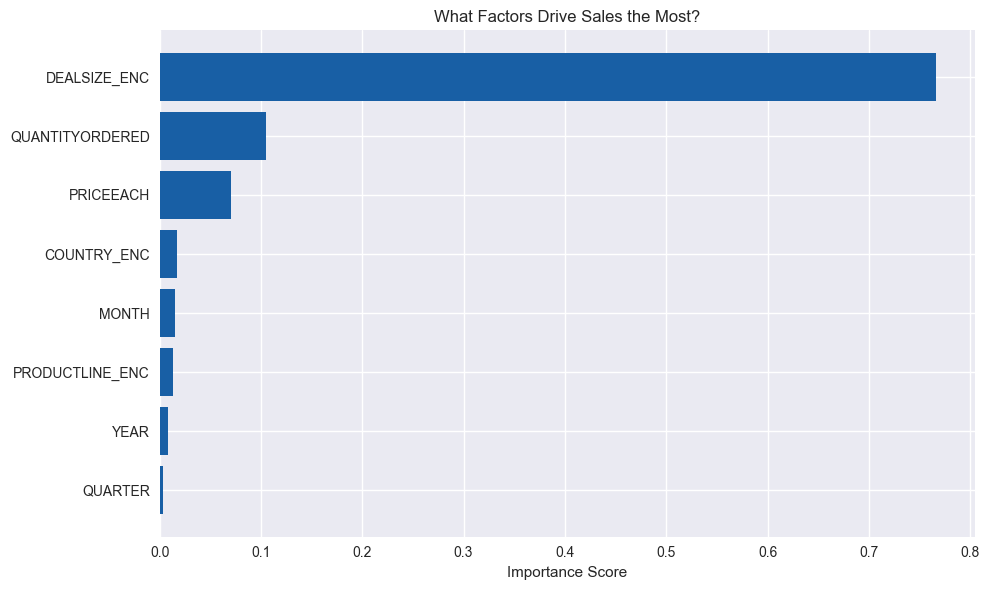


Top factor driving sales: DEALSIZE_ENC


In [23]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Model trained successfully!")
print(f"R² Score: {r2:.2f} (closer to 1.0 is better)")
print(f"Mean Absolute Error: ${mae:.2f}")

# Feature importance chart
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(importance_df['Feature'], 
         importance_df['Importance'], 
         color='#185FA5')
plt.title('What Factors Drive Sales the Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop factor driving sales:", 
      importance_df.iloc[-1]['Feature'])

In [24]:
#gen ai 


from groq import Groq
client=Groq(api_key="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")
business_summary = f"""
You are a senior business analyst at MResult, a data analytics company.
Here is the sales data summary you must use to answer questions:

OVERALL PERFORMANCE:
- Total Revenue: $10,032,628.85
- Best Year: 2004
- Total Orders: {len(df)}

PRODUCT LINE PERFORMANCE:
- Classic Cars: $3,919,615.66 (top performer)
- Vintage Cars: $1,903,150.84
- Motorcycles: $1,166,388.34
- Trucks and Buses: $1,127,789.84
- Planes: $975,003.57
- Ships: $714,437.13
- Trains: $226,243.47

COUNTRY PERFORMANCE:
- Top Country: USA
- November is the peak sales month ($2,118,885.67)
- December is surprisingly low due to B2B budget cycles

ML MODEL INSIGHTS:
- Sales prediction model accuracy: 88%
- Biggest driver of sales: Deal Size
- Average order value: ${df['SALES'].mean():.2f}
- Mean prediction error: $343.91

Answer questions clearly and concisely like a business consultant.
Always give actionable recommendations based on the data.
"""

def ask_ai_analyst(question):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": business_summary},
            {"role": "user", "content": question}
        ]
    )
    answer = response.choices[0].message.content
    print(f"\n🧑 You: {question}")
    print(f"\n🤖 AI Analyst: {answer}")
    print("\n" + "="*60)
    return answer

# Test with 3 business questions
ask_ai_analyst("Which product line should we invest more in and why?")
ask_ai_analyst("What is the best strategy to increase sales in Q1?")
ask_ai_analyst("Which market should we expand to next and why?")




🧑 You: Which product line should we invest more in and why?

🤖 AI Analyst: Based on the data, I recommend investing more in the "Classic Cars" product line. It is currently the top performer, generating $3,919,615.66 in revenue, which is approximately 39% of the total revenue. 

To further capitalize on this success, I suggest:

1. Increasing marketing efforts targeted at the Classic Cars segment to attract more customers.
2. Expanding the Classic Cars product portfolio to cater to a wider range of customer preferences.
3. Enhancing the overall customer experience for Classic Cars customers to increase loyalty and retention.

By investing more in the Classic Cars product line, we can potentially increase revenue and further solidify its position as the top performer.


🧑 You: What is the best strategy to increase sales in Q1?

🤖 AI Analyst: To increase sales in Q1, I recommend the following strategies based on the data:

1. **Target high-value deals**: Since the biggest driver of sale

"Based on the data provided, we don't have specific information about individual country performance beyond the fact that the USA is the top-performing country. However, we can make an educated decision by analyzing the existing product line and customer behavior.\n\nConsidering the top-performing product line is Classic Cars, I would recommend expanding to markets with a strong affinity for classic vehicles, such as the UK, Germany, or Japan. These countries have a rich automotive history and a significant number of car enthusiasts, which could translate to a high demand for classic cars.\n\nAdditionally, since the average order value is $3553.89, it's likely that our products appeal to a niche audience with a certain level of disposable income. Therefore, targeting countries with a high GDP per capita and a strong culture of luxury goods could be beneficial.\n\nActionable recommendation: Conduct market research in the UK, Germany, and Japan to assess the demand for classic cars and g

In [ ]:
# Interactive AI Analyst
print("=" * 60)
print("   SALES INTELLIGENCE AI ANALYST")
print("   Powered by Groq LLM + Your Sales Data")
print("=" * 60)
print("Type your business question and press Enter")
print("Type 'exit' to stop")
print("=" * 60)

while True:
    question = input("\n🧑 Your question: ")
    if question.lower() == 'exit':
        print("\n✅ AI Analyst session ended!")
        break
    if question.strip() == "":
        print("Please type a question!")
        continue
    ask_ai_analyst(question)